# 6. Perceptrón multicapa

**Objetivo.** Entrenar un MLP completo, primero con operaciones explícitas y después con las abstracciones de PyTorch.

Resolveremos XOR. La capa oculta transforma el espacio de entrada; la capa de salida separa linealmente esa nueva representación.

In [1]:
import random
import torch
import matplotlib.pyplot as plt

SEMILLA = 42
random.seed(SEMILLA)
torch.manual_seed(SEMILLA)
torch.set_printoptions(precision=3, sci_mode=False)
print(f"PyTorch {torch.__version__} · semilla {SEMILLA}")

PyTorch 2.14.0 · semilla 42


In [2]:
X_base = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y_base = torch.tensor([[0.], [1.], [1.], [0.]])
X = X_base.repeat(100, 1) + 0.04 * torch.randn(400, 2)
y = y_base.repeat(100, 1)
perm = torch.randperm(len(X))
train, test = perm[:320], perm[320:]
print(f"observaciones: {len(X)} · entrenamiento: {len(train)} · prueba: {len(test)}")

observaciones: 400 · entrenamiento: 320 · prueba: 80


## Implementación explícita

Los parámetros son tensores entrenables. La entropía cruzada binaria con *logits* combina sigmoid y la pérdida de forma numéricamente estable.

pérdida final=0.0145 · exactitud test=1.000


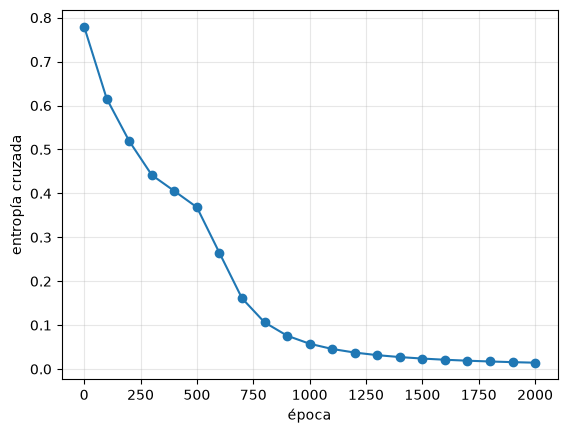

In [3]:
W1 = (torch.randn(2, 8) * 0.5).requires_grad_()
b1 = torch.zeros(8, requires_grad=True)
W2 = (torch.randn(8, 1) * 0.5).requires_grad_()
b2 = torch.zeros(1, requires_grad=True)
parametros = [W1, b1, W2, b2]

def mlp(entradas):
    return torch.relu(entradas @ W1 + b1) @ W2 + b2

historia = []
for epoca in range(2001):
    perdida = torch.nn.functional.binary_cross_entropy_with_logits(mlp(X[train]), y[train])
    perdida.backward()
    with torch.no_grad():
        for p in parametros:
            p -= 0.1 * p.grad
            p.grad.zero_()
    if epoca % 100 == 0:
        historia.append((epoca, perdida.item()))

with torch.no_grad():
    pred = (mlp(X[test]) >= 0).float()
    exactitud = (pred == y[test]).float().mean().item()
print(f"pérdida final={historia[-1][1]:.4f} · exactitud test={exactitud:.3f}")
plt.plot([e for e, _ in historia], [v for _, v in historia], marker="o")
plt.xlabel("época"); plt.ylabel("entropía cruzada"); plt.grid(alpha=.3);
plt.savefig("imagenes/perdida_mlp.png", dpi=160, bbox_inches="tight")
plt.show()

## Frontera de decisión

La probabilidad predicha muestra la frontera no lineal aprendida por la composición de capas.

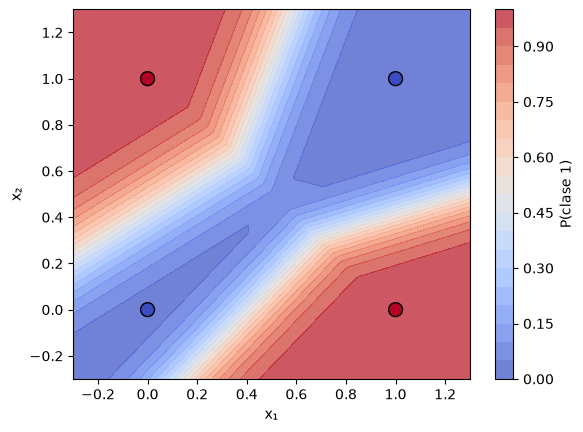

In [4]:
gx, gy = torch.meshgrid(torch.linspace(-.3, 1.3, 160), torch.linspace(-.3, 1.3, 160), indexing="xy")
rejilla = torch.stack([gx.flatten(), gy.flatten()], dim=1)
with torch.no_grad():
    prob = torch.sigmoid(mlp(rejilla)).reshape(gx.shape)
plt.contourf(gx, gy, prob, levels=20, cmap="coolwarm", alpha=.75)
plt.colorbar(label="P(clase 1)")
plt.scatter(X_base[:, 0], X_base[:, 1], c=y_base[:, 0], cmap="coolwarm", edgecolor="black", s=100)
plt.xlabel("x₁"); plt.ylabel("x₂");
plt.savefig("imagenes/frontera_mlp.png", dpi=160, bbox_inches="tight")
plt.show()

## La misma arquitectura con `torch.nn`

`nn.Sequential` registra las capas y sus parámetros. El optimizador aplica las actualizaciones, pero el ciclo conceptual no cambia.

In [5]:
modelo = torch.nn.Sequential(
    torch.nn.Linear(2, 8),
    torch.nn.ReLU(),
    torch.nn.Linear(8, 1),
)
criterio = torch.nn.BCEWithLogitsLoss()
optimizador = torch.optim.Adam(modelo.parameters(), lr=0.03)

for _ in range(300):
    optimizador.zero_grad()
    perdida = criterio(modelo(X[train]), y[train])
    perdida.backward()
    optimizador.step()

with torch.no_grad():
    pred = (modelo(X[test]) >= 0).float()
print(modelo)
print("exactitud test:", (pred == y[test]).float().mean().item())

Sequential(
  (0): Linear(in_features=2, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)
exactitud test: 1.0


## Reto final

1. Cambia el número de neuronas ocultas entre 1, 2, 4, 8 y 32.
2. Sustituye ReLU por `Tanh` y razona qué cambia.
3. Introduce validación y detén el entrenamiento cuando su pérdida deje de mejorar.
4. Explica por qué el MLP resuelve XOR y el perceptrón simple no.

**Cierre:** ya tenemos los componentes esenciales: tensores, transformaciones lineales, activaciones, pérdida, gradientes, optimización y evaluación.